# Apple ripeness & size estimation from one RGB-D image
Reproduction of the inference pipeline from **"Foundation Model-Based Apple Ripeness and Size
Estimation for Selective Harvesting"** (arXiv:2502.01850v1, 2025;
[arXiv page](https://arxiv.org/abs/2502.01850)).

- **Author code**: [zhukeyi-stan/Fuji_Ripeness_And_Size_Estimation](https://github.com/zhukeyi-stan/Fuji_Ripeness_And_Size_Estimation) @ commit `a0b71062800490d62165d0c6e41c0afd933943d9`
- **Data & fine-tuned checkpoint**: [Kaggle: Fuji Ripeness & Size Dataset](https://www.kaggle.com/datasets/zhukeyi1/fuji-ripeness-and-size-dataset) (62 GB total; we download 4 selected files only)
- **Segment Anything**: official ViT-H checkpoint (`sam_vit_h_4b8939.pth`, the author default in `inference.py`)

**Scope — one example, not a benchmark.** We run the author's documented inference path on the
exact sample from `inference.py` (`test/images/_MG_2657_24.png`, an RGB-D image from the UdL
portion of the dataset): Grounding-DINO (Swin-B, fine-tuned) detects ripe/unripe apples with the
prompt `"ripe. unripe."`, SAM segments each box, and the author's six size-estimation algorithms
(2D: bbox / max_dist_mask "2D-LSeg" / hough_mask; 3D: largest_segment / least_square /
bounded_ransac) estimate each apple's equatorial diameter in mm from the aligned depth map.
Training, dataset-wide benchmarks (Table 1, Figures 9–10) and the journal version
(Comput. Electron. Agric. 2025) are out of scope. One image is **not** a verification of the
paper's dataset-level results.

**Runtime**: T4 GPU recommended (Runtime ▸ Change runtime type ▸ T4 GPU). A CPU runtime also
works but the two ViT models take several minutes per image on CPU. The same notebook runs on
both; the pipeline detects the device automatically.

**AI-assisted setup notice / AI支援の設定に関する注記**: The author's scientific code
(`inference.py`, `utils/sizing_algorithms.py`, `utils/pcloud_operation.py`, `utils/plot.py`)
is copied verbatim with citations. The environment setup, the Python 3.11 sub-environment, and
the path/device glue are AI-generated (the authors did not provide this Colab implementation).
The executed example and listed checks were validated, but untested behavior is not guaranteed.
/ 論文の科学コードは原文のまま引用し、環境構築とパス/デバイスの接着コードはAIが作成しました
(著者はこのColab実装を提供していません)。実行済みの例と記載の検証は有効ですが、未検証の
動作は保証されません。

**Expected duration / 所要時間**: ~15–25 min total (≈10 min installs + ≈4 GB downloads +
1–10 min inference depending on device). / 目安: 全体で15〜25分程度。

## 1. Why a Python 3.11 sub-environment? / なぜ Python 3.11 サブ環境か
The author's stack is mmdetection 3.3.0 + mmcv 2.1.0 + torch (README pins torch 1.13.1+cu117).
Prebuilt `mmcv` wheels end at torch 2.4, and mmdet 3.3.0 requires `mmcv<2.2.0` (asserted in
`mmdet/__init__.py`). Colab's 2026 kernel is Python 3.13 + torch 2.11, which has no compatible
mmcv build, so we create a pinned **Python 3.11** virtual environment with `uv` inside the VM
(`/content/venv311`) and run all science there via subprocess. The notebook kernel itself only
orchestrates. This keeps the author's version pin faithful while running on both CPU and T4
runtimes. / 著者の環境は mmdet 3.3.0 + mmcv 2.1.0 で、2026年のColabカーネル(py3.13/torch 2.11)
には互換wheelが無いため、VM内に `uv` で Python 3.11 環境を作り、そこで科学計算を実行します。

In [ ]:
%pip install -q uv
import sys, importlib.util
print("kernel python:", sys.version.split()[0])
spec = importlib.util.find_spec("uv")
print("uv installed:", spec is not None)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 85.9 MB/s eta 0:00:00


kernel python: 3.13.15
uv installed: True


Create the Python 3.11 venv and install the author-pinned torch build (2.1.2+cu121 — the
closest maintained build to the README's `torch==1.13.1+cu117` that has wheels for Python 3.11;
cu121 wheels run on CPU-only VMs and on T4 GPUs alike). / Python 3.11 venv を作成し、著者指定の
torch系(cu121)をインストールします。CPUランタイムでもT4でも動作します。

In [ ]:
import subprocess
def sh(cmd, timeout=3600):
    import os as _os
    print("$", cmd[:140], flush=True)
    _env = dict(_os.environ); _env["MPLBACKEND"] = "Agg"  # Colab leaks an inline backend the venv cannot use
    p = subprocess.run(["bash", "-lc", cmd], capture_output=True, text=True, timeout=timeout, env=_env)
    print(p.stdout[-1200:]); print(p.stderr[-500:])
    assert p.returncode == 0, f"FAILED: {cmd}\n{p.stdout[-800:]}\n{p.stderr[-800:]}"
    return p

sh("python3 -m uv venv /content/venv311 --python 3.11")
sh("/content/venv311/bin/python -V")
sh("uv pip install --python /content/venv311/bin/python 'numpy==1.26.4' torch==2.1.2 torchvision==0.16.2 --index-url https://download.pytorch.org/whl/cu121")

$ python3 -m uv venv /content/venv311 --python 3.11



 Downloaded cpython-3.11.17-linux-x86_64-gnu (download)
Using CPython 3.11.17
Creating virtual environment at: venv311
Activate with: source venv311/bin/activate

$ /content/venv311/bin/python -V


Python 3.11.17


$ uv pip install --python /content/venv311/bin/python 'numpy==1.26.4' torch==2.1.2 torchvision==0.16.2 --index-url https://download.pytorch.or



ded torchvision
 Downloaded numpy
 Downloaded triton
 Downloaded torch
Prepared 18 packages in 43.03s
Installed 18 packages in 385ms
 + certifi==2022.12.7
 + charset-normalizer==2.1.1
 + filelock==3.32.3
 + fsspec==2026.7.0
 + idna==3.4
 + jinja2==3.1.6
 + markupsafe==3.0.3
 + mpmath==1.3.0
 + networkx==3.6.1
 + numpy==1.26.4
 + pillow==12.3.0
 + requests==2.28.1
 + sympy==1.14.0
 + torch==2.1.2+cu121
 + torchvision==0.16.2+cu121
 + triton==2.1.0
 + typing-extensions==4.16.0
 + urllib3==1.26.13



CompletedProcess(args=['bash', '-lc', "uv pip install --python /content/venv311/bin/python 'numpy==1.26.4' torch==2.1.2 torchvision==0.16.2 --index-url https://download.pytorch.org/whl/cu121"], returncode=0, stdout='', stderr='Using Python 3.11.17 environment at: venv311\nResolved 18 packages in 1.08s\nDownloading sympy (6.0MiB)\nDownloading numpy (17.4MiB)\nDownloading networkx (2.0MiB)\nDownloading pillow (6.6MiB)\nDownloading torch (2.0GiB)\nDownloading triton (85.1MiB)\nDownloading torchvision (6.5MiB)\n Downloaded networkx\n Downloaded sympy\n Downloaded pillow\n Downloaded torchvision\n Downloaded numpy\n Downloaded triton\n Downloaded torch\nPrepared 18 packages in 43.03s\nInstalled 18 packages in 385ms\n + certifi==2022.12.7\n + charset-normalizer==2.1.1\n + filelock==3.32.3\n + fsspec==2026.7.0\n + idna==3.4\n + jinja2==3.1.6\n + markupsafe==3.0.3\n + mpmath==1.3.0\n + networkx==3.6.1\n + numpy==1.26.4\n + pillow==12.3.0\n + requests==2.28.1\n + sympy==1.14.0\n + torch==2.1.2+

Install mmdetection 3.3.0 and mmcv 2.1.0 (prebuilt cp311 wheel from the official OpenMMLab
index for torch 2.1), plus the remaining author-pinned dependencies (README steps 2–5:
opencv-python, scipy, matplotlib, fairscale, transformers, segment-anything).
/ 残りの依存関係(mmcvの公式wheel、mmdet、Segment Anything等)をインストールします。

In [ ]:
sh("uv pip install --python /content/venv311/bin/python mmcv==2.1.0 -f https://download.openmmlab.com/mmcv/dist/cu121/torch2.1/index.html")
sh("uv pip install --python /content/venv311/bin/python mmengine mmdet==3.3.0 opencv-python scipy matplotlib fairscale 'transformers<4.50' 'git+https://github.com/facebookresearch/segment-anything.git'")

$ uv pip install --python /content/venv311/bin/python mmcv==2.1.0 -f https://download.openmmlab.com/mmcv/dist/cu121/torch2.1/index.html



package in 14ms
Installed 22 packages in 58ms
 + addict==2.4.0
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.66.1
 + kiwisolver==1.5.1
 + markdown-it-py==4.2.0
 + matplotlib==3.11.2
 + mdurl==0.1.2
 + mmcv==2.1.0
 + mmengine==0.10.7
 - numpy==1.26.4
 + numpy==2.4.6
 + opencv-python==5.0.0.93
 + packaging==26.3
 + platformdirs==4.12.3
 + pygments==2.21.0
 + pyparsing==3.3.3
 + python-dateutil==2.9.0.post0
 + pyyaml==6.0.3
 + rich==15.0.0
 + six==1.17.0
 + termcolor==3.3.0
 + yapf==0.43.0

$ uv pip install --python /content/venv311/bin/python mmengine mmdet==3.3.0 opencv-python scipy matplotlib fairscale 'transformers<4.50' 'git+



 fairscale==0.4.13
 Downloaded scipy
Prepared 14 packages in 2.82s
Installed 14 packages in 86ms
 + fairscale==0.4.13
 + hf-xet==1.7.0
 + huggingface-hub==0.36.2
 + mmdet==3.3.0
 + pycocotools==2.0.11
 + regex==2026.9.29
 + safetensors==0.8.0
 + scipy==1.17.1
 + segment-anything==1.0 (from git+https://github.com/facebookresearch/segment-anything.git@dca509fe793f601edb92606367a655c15ac00fdf)
 + shapely==2.1.2
 + terminaltables==3.1.10
 + tokenizers==0.21.4
 + tqdm==4.70.1
 + transformers==4.49.0



CompletedProcess(args=['bash', '-lc', "uv pip install --python /content/venv311/bin/python mmengine mmdet==3.3.0 opencv-python scipy matplotlib fairscale 'transformers<4.50' 'git+https://github.com/facebookresearch/segment-anything.git'"], returncode=0, stdout='', stderr='Using Python 3.11.17 environment at: venv311\n   Updating https://github.com/facebookresearch/segment-anything.git (HEAD)\n    Updated https://github.com/facebookresearch/segment-anything.git (dca509fe793f601edb92606367a655c15ac00fdf)\nResolved 51 packages in 6.82s\n   Building fairscale==0.4.13\nDownloading hf-xet (4.0MiB)\nDownloading scipy (33.7MiB)\nDownloading transformers (9.5MiB)\nDownloading mmdet (2.1MiB)\n   Building segment-anything @ git+https://github.com/facebookresearch/segment-anything.git@dca509fe793f601edb92606367a655c15ac00fdf\nDownloading shapely (3.0MiB)\nDownloading tokenizers (3.0MiB)\n Downloaded mmdet\n Downloaded tokenizers\n Downloaded shapely\n Downloaded hf-xet\n Downloaded transformers\n 

Re-pin numpy to 1.26.4: torch 2.1.2 cannot use numpy 2.x ("Numpy is not available" in
`torch.from_numpy`), and the resolver above may upgrade it. This ordering makes the pin stick.
/ torch 2.1.2 は numpy 2.x を使えないため、最後に numpy 1.26.4 を再固定します。

In [ ]:
sh("uv pip install --python /content/venv311/bin/python 'numpy==1.26.4'")

$ uv pip install --python /content/venv311/bin/python 'numpy==1.26.4'



Using Python 3.11.17 environment at: venv311
Resolved 1 package in 76ms
 Downloaded numpy
Prepared 1 package in 455ms
Uninstalled 1 package in 16ms
Installed 1 package in 17ms
 - numpy==2.4.6
 + numpy==1.26.4



CompletedProcess(args=['bash', '-lc', "uv pip install --python /content/venv311/bin/python 'numpy==1.26.4'"], returncode=0, stdout='', stderr='Using Python 3.11.17 environment at: venv311\nResolved 1 package in 76ms\nDownloading numpy (17.4MiB)\n Downloaded numpy\nPrepared 1 package in 455ms\nUninstalled 1 package in 16ms\nInstalled 1 package in 17ms\n - numpy==2.4.6\n + numpy==1.26.4\n')

Verify the sub-environment: import the exact APIs the author's `inference.py` uses and print
versions. This fails loudly if the stack is broken. / サブ環境の全importとバージョンを確認します。

In [ ]:
verify = '''
import torch, mmcv, mmdet, cv2, scipy, numpy
from mmdet.apis import init_detector, inference_detector
from segment_anything import sam_model_registry, SamPredictor
print('torch', torch.__version__, '| cuda build', torch.version.cuda, '| cuda avail', torch.cuda.is_available())
print('numpy', numpy.__version__, '| mmcv', mmcv.__version__, '| mmdet', mmdet.__version__)
print('OK: all author APIs import')
'''
open("/content/verify_env.py", "w").write(verify)
sh("/content/venv311/bin/python /content/verify_env.py", timeout=600)

$ /content/venv311/bin/python /content/verify_env.py


torch 2.1.2+cu121 | cuda build 12.1 | cuda avail True
numpy 1.26.4 | mmcv 2.1.0 | mmdet 3.3.0
OK: all author APIs import




CompletedProcess(args=['bash', '-lc', '/content/venv311/bin/python /content/verify_env.py'], returncode=0, stdout='torch 2.1.2+cu121 | cuda build 12.1 | cuda avail True\nnumpy 1.26.4 | mmcv 2.1.0 | mmdet 3.3.0\nOK: all author APIs import\n', stderr='')

## 2. Minimal data & weights acquisition / 最小限のデータと重みの入手
The Kaggle dataset is 62.4 GB — never download it whole. We fetch exactly four files with
`kagglehub` selective download (public dataset, no login): the fine-tuned Grounding-DINO config +
checkpoint, and the sample RGB image + aligned depth map used by the author's `inference.py`.
Sizes are asserted against the Kaggle file-list metadata recorded during reproduction
(gdino/gdino_0.pth 937,421,221 B; gdino/gdino_b_full.py 18,678 B; test/images/_MG_2657_24.png
1,668,437 B; test/depths/_MG_2657_24.npy 13,520,080 B). / 62.4GBのデータセット全体ではなく、
著者の `inference.py` が参照する4ファイルだけをkagglehubで選択ダウンロードします。

In [ ]:
import os, hashlib, kagglehub

EXPECTED = {
    "gdino/gdino_0.pth": 937421221,
    "gdino/gdino_b_full.py": 18678,
    "test/images/_MG_2657_24.png": 1668437,
    "test/depths/_MG_2657_24.npy": 13520080,
}
paths = {}
for rel, size in EXPECTED.items():
    p = kagglehub.dataset_download("zhukeyi1/fuji-ripeness-and-size-dataset", path=rel)
    got = os.path.getsize(p)
    assert got == size, f"{rel}: {got} != {size} bytes"
    h = hashlib.sha256(open(p, "rb").read(1 << 24)).hexdigest() if got < 1 << 24 else None
    if h is None:  # stream large file
        hh = hashlib.sha256()
        with open(p, "rb") as f:
            for chunk in iter(lambda: f.read(1 << 22), b""):
                hh.update(chunk)
        h = hh.hexdigest()
    paths[rel] = p
    print(f"{rel}: {got} bytes  sha256={h[:16]}...")
import json as _json
_json.dump(paths, open("/content/asset_paths.json", "w"))
print("asset paths recorded to /content/asset_paths.json")

  0%|          | 0.00/894M [00:00<?, ?B/s]

  0%|          | 1.00M/894M [00:01<20:45, 752kB/s]

  0%|          | 2.00M/894M [00:01<10:39, 1.46MB/s]

  0%|          | 3.00M/894M [00:01<06:43, 2.31MB/s]

  1%|          | 5.00M/894M [00:01<03:38, 4.27MB/s]

...

 70%|██████▉   | 9.00M/12.9M [00:02<00:00, 8.42MB/s]

 85%|████████▌ | 11.0M/12.9M [00:02<00:00, 10.6MB/s]

100%|██████████| 12.9M/12.9M [00:02<00:00, 11.9MB/s]

100%|██████████| 12.9M/12.9M [00:02<00:00, 5.56MB/s]

test/depths/_MG_2657_24.npy: 13520080 bytes  sha256=e4ec773f94b62a9b...
asset paths recorded to /content/asset_paths.json


Download the official **Segment Anything ViT-H** checkpoint (2.56 GB; the author default
`sam_version='vit_h'` in `inference.py:51`). Streamed with progress; size asserted against the
official release. / SAM ViT-Hの公式チェックポイント(2.56GB)を公式URLからダウンロードします。

In [ ]:
import os, urllib.request
sam_path = "/content/assets/sam_vit_h_4b8939.pth"
SAM_SIZE = 2564550879  # official release size, asserted after download
os.makedirs("/content/assets", exist_ok=True)
if not (os.path.exists(sam_path) and os.path.getsize(sam_path) == SAM_SIZE):
    url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
    def hook(n, bs, total):
        if n % 400 == 0:
            print(f"{min(n*bs/1e9, total/1e9):.2f}/{total/1e9:.2f} GB", flush=True)
    urllib.request.urlretrieve(url, sam_path, hook)
assert os.path.getsize(sam_path) == SAM_SIZE, os.path.getsize(sam_path)
assert open(sam_path, "rb").read(2) == b"PK"  # torch zip container, not HTML
print("SAM ViT-H checkpoint OK:", sam_path, os.path.getsize(sam_path), "bytes")

0.00/2.56 GB


0.00/2.56 GB


0.01/2.56 GB


0.01/2.56 GB


0.01/2.56 GB


...

2.55/2.56 GB


2.56/2.56 GB


2.56/2.56 GB


2.56/2.56 GB


SAM ViT-H checkpoint OK: /content/assets/sam_vit_h_4b8939.pth 2564550879 bytes


### Verify the sample bytes and depth statistics
The sample image is 1300×1300 RGB; the aligned depth map is float64 meters. The author's outlier
removal treats z∈[0.2, 6] m as valid (utils/pcloud_operation.py). / サンプルの画像と深度の実バイトを検証します。

In [ ]:
import numpy as np
from PIL import Image
img = np.array(Image.open(paths["test/images/_MG_2657_24.png"]))
depth = np.load(paths["test/depths/_MG_2657_24.npy"])
print("image:", img.shape, img.dtype)
print("depth:", depth.shape, depth.dtype, "| min %.2f max %.2f m" % (depth.min(), depth.max()))
valid = ((depth > 0.2) & (depth < 6.0)).sum()
print(f"valid px in (0.2, 6) m: {valid} ({100*valid/depth.size:.1f}%)")

image: (1300, 1300, 3) uint8
depth: (1300, 1300) float64 | min 0.00 max 11.48 m
valid px in (0.2, 6) m: 760254 (45.0%)


### Input preview: RGB image and depth map
Show the actual sample before any model runs (left: RGB from the UdL RealSense D435i capture;
right: aligned depth in meters). This is the real input the reproduction handles.
/ 推論前に入力(RGBと深度)を可視化します。

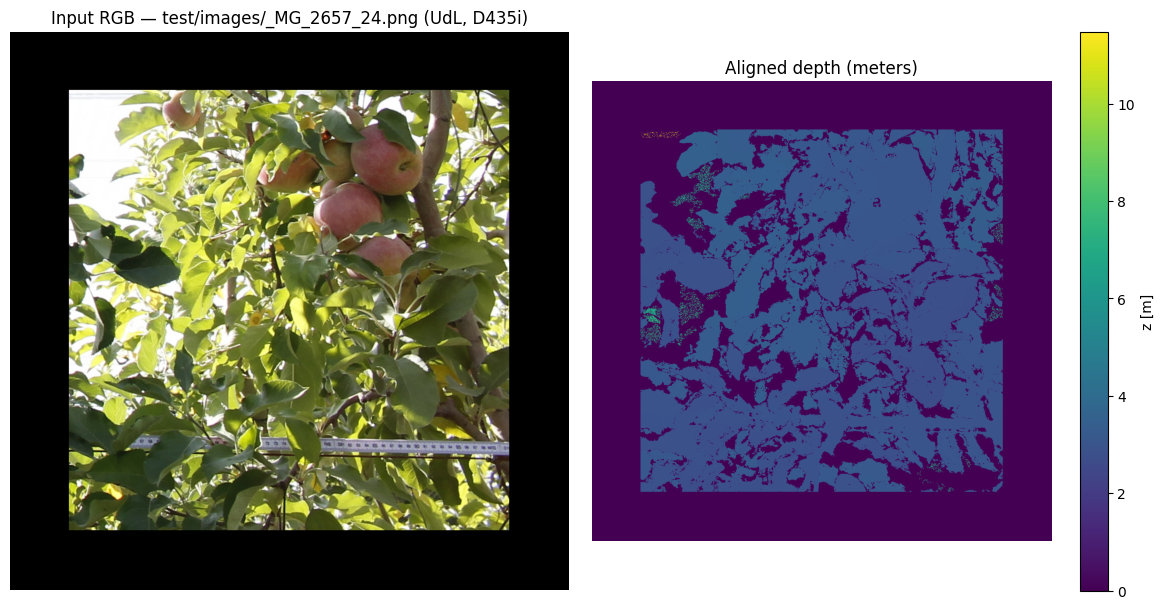

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img)
axes[0].set_title("Input RGB — test/images/_MG_2657_24.png (UdL, D435i)")
d = axes[1].imshow(depth, cmap="viridis")
axes[1].set_title("Aligned depth (meters)")
fig.colorbar(d, ax=axes[1], label="z [m]")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Author pipeline (verbatim) written for the sub-environment
The next three cells write `/content/pipeline.py`: the author's `inference.py` flow and the
`utils/` functions copied verbatim (point-cloud generation, percentile outlier removal, all six
size algorithms), plus the `utils/plot.py` overlay. Only paths, the device line, and the output
directory are adapted; each is cited in comments. / 著者コードを原文のまま `/content/pipeline.py`
に書き込みます(パス・デバイス・出力先のみ適応)。

In [ ]:
part1 = r'''
# ---- utils/pcloud_operation.py (verbatim; repo a0b7106) ----
import numpy as np
import scipy, scipy.spatial, scipy.optimize
import cv2
import random
import json, os, time

r_min, r_max = 20, 50  # sizing_algorithms.py:9-10 (mm)

def gen_pc(img, depth, bbox, mask, focal_length):
    def transform(px, py, z, f):
        x = px / f * z
        y = py / f * z
        return x, y
    pc = []
    h, w, _ = img.shape
    x1, y1, x2, y2 = [int(v) for v in bbox]
    for x_ in range(x1, x2):
        for y_ in range(y1, y2):
            if mask[y_, x_]:
                z = depth[y_, x_]
                if z == 0: continue
                x, y = transform(x_ - w / 2, y_ - h / 2, z, focal_length)
                pc.append([x, y, z, img[y_, x_, 2], img[y_, x_, 1], img[y_, x_, 0]])
    return np.array(pc)

def outlier_removal(pc, low_bound, high_bound):
    z_low, z_high = 0.2, 6
    if low_bound == 0 and high_bound == 100: return pc
    pc = pc[pc[:, 2] < z_high, :]
    pc = pc[z_low < pc[:, 2], :]
    ind = np.argsort(pc[:, 2]); sorted_pc = pc[ind, :]
    n = sorted_pc.shape[0]
    return sorted_pc[int(np.floor(n * low_bound / 100.)):int(np.ceil(n * high_bound / 100.)), :]

def get_mean_depth(depths, removal_rate):
    depths = np.array(depths); depths = depths[depths > 0]
    residues = np.logical_and(depths >= np.percentile(depths, removal_rate[0]),
                              depths <= np.percentile(depths, removal_rate[1]))
    return np.mean(depths[residues])

# ---- utils/sizing_algorithms.py (verbatim logic) ----
def largest_segment(points, r_min=r_min, r_max=r_max):
    try:
        points = points[scipy.spatial.ConvexHull(points).vertices]
        dist_mat = scipy.spatial.distance_matrix(points, points)
    except Exception:
        dist_mat = scipy.spatial.distance_matrix(points, points)
    return np.clip(dist_mat.max() * 1000, 2 * r_min, 2 * r_max)

def least_square_fit(spX, spY, spZ, loss="arctan", ftol=10e-7, xtol=10e-7, jac="3-point"):
    init_values = [0.04, np.mean(spX), np.mean(spY), np.mean(spZ)]
    bounds = ([r_min/1000, init_values[1]-0.4, init_values[2]-0.4, init_values[3]-0.4],
              [r_max/1000, init_values[1]+0.4, init_values[2]+0.4, init_values[3]+0.4])
    def sphere_function(x, *args, **kwargs):
        r, x0, y0, z0 = x
        X, Y, Z = args
        return np.sqrt((X-x0)**2 + (Y-y0)**2 + (Z-z0)**2) - r
    result = scipy.optimize.least_squares(sphere_function, init_values, loss=loss,
        ftol=ftol, xtol=xtol, bounds=bounds, max_nfev=250, args=(spX, spY, spZ), jac=jac)
    result.x[0] = np.clip(result.x[0], r_min/1000, r_max/1000)
    return result

def bounded_sphere_ransac_fit(pts, thresh=0.01, maxIteration=1000):
    n_points = pts.shape[0]; best_inliers = []; best_center = []; best_radius = -1
    for it in range(maxIteration):
        id_samples = random.sample(range(0, n_points), 4)
        pt_samples = pts[id_samples]
        d_matrix = np.ones((4, 4))
        for i in range(4):
            d_matrix[i, 0] = pt_samples[i, 0]; d_matrix[i, 1] = pt_samples[i, 1]; d_matrix[i, 2] = pt_samples[i, 2]
        M11 = np.linalg.det(d_matrix)
        if M11 == 0: continue
        for i in range(4):
            d_matrix[i, 0] = np.dot(pt_samples[i], pt_samples[i]); d_matrix[i, 1] = pt_samples[i, 1]; d_matrix[i, 2] = pt_samples[i, 2]
        M12 = np.linalg.det(d_matrix)
        for i in range(4):
            d_matrix[i, 0] = np.dot(pt_samples[i], pt_samples[i]); d_matrix[i, 1] = pt_samples[i, 0]; d_matrix[i, 2] = pt_samples[i, 2]
        M13 = np.linalg.det(d_matrix)
        for i in range(4):
            d_matrix[i, 0] = np.dot(pt_samples[i], pt_samples[i]); d_matrix[i, 1] = pt_samples[i, 0]; d_matrix[i, 2] = pt_samples[i, 1]
        M14 = np.linalg.det(d_matrix)
        for i in range(4):
            d_matrix[i, 0] = np.dot(pt_samples[i], pt_samples[i]); d_matrix[i, 1] = pt_samples[i, 0]; d_matrix[i, 2] = pt_samples[i, 1]; d_matrix[i, 3] = pt_samples[i, 2]
        M15 = np.linalg.det(d_matrix)
        center = [0.5*(M12/M11), -0.5*(M13/M11), 0.5*(M14/M11)]
        radius = np.sqrt(np.dot(center, center) - (M15/M11))
        radius = np.clip(radius, r_min/1000, r_max/1000)
        dist_pt = np.linalg.norm(center - pts, axis=1)
        pt_id_inliers = np.where(np.abs(dist_pt - radius) <= thresh)[0]
        if len(pt_id_inliers) > len(best_inliers):
            best_inliers = pt_id_inliers; best_center = center; best_radius = radius
    return best_center, best_radius, best_inliers

def max_dist_mask(depth, mask, focal_length, removal_rate, r_min=r_min, r_max=r_max):
    points = []; depths = []
    y, x = np.where(mask)
    for i in range(x.shape[0]):
        points.append([y[i], x[i]])
        if depth[y[i], x[i]] < 0.5: continue
        depths.append(depth[y[i], x[i]])
    if len(points) < 50 or len(depths) < 50: return -1
    average_depth = get_mean_depth(depths, removal_rate)
    if average_depth < 0.5: return -1
    points = np.array(points)
    try:
        points = points[scipy.spatial.ConvexHull(points).vertices]
        dist_mat = scipy.spatial.distance_matrix(points, points)
    except Exception:
        dist_mat = scipy.spatial.distance_matrix(points, points)
    d = dist_mat.max() / focal_length * average_depth * 1000
    return float(np.clip(d, 2*r_min, 2*r_max))

def hough_mask(depth, mask, focal_length, removal_rate, r_min=r_min, r_max=r_max):
    points = []; depths = []
    y, x = np.where(mask)
    img = mask.astype(np.uint8) * 255
    for i in range(x.shape[0]):
        points.append([y[i], x[i]])
        if depth[y[i], x[i]] < 0.5: continue
        depths.append(depth[y[i], x[i]])
    if len(points) < 50 or len(depths) < 50: return -1
    circles = cv2.HoughCircles(img, cv2.HOUGH_GRADIENT, dp=8, minDist=50, param1=100, param2=80, minRadius=10, maxRadius=200)
    if circles is None: return -1
    average_depth = get_mean_depth(depths, removal_rate)
    d = circles[0, 0, 2] * 2 / focal_length * average_depth * 1000
    return float(np.clip(d, 2*r_min, 2*r_max))

def bbox_estimation(depth, mask, bbox, focal_length, removal_rate, r_min=r_min, r_max=r_max):
    points = []; depths = []
    x1, y1, x2, y2 = bbox
    d_ = np.max([x2 - x1, y2 - y1])
    y, x = np.where(mask)
    for i in range(x.shape[0]):
        points.append([y[i], x[i]])
        if depth[y[i], x[i]] < 0.5: continue
        depths.append(depth[y[i], x[i]])
    if len(points) < 50 or len(depths) < 50: return -1
    average_depth = get_mean_depth(depths, removal_rate)
    d = d_ / focal_length * average_depth * 1000
    return float(np.clip(d, 2*r_min, 2*r_max))

def size_estimation(algorithm, args):
    if algorithm in ['largest_segment', 'least_square', 'bounded_ransac']:
        img, depth, bbox, mask, focal_length, removal_rate = args
        pc = gen_pc(img, depth, bbox, mask, focal_length)
        pc = pc[:, :3]
        pc_filtered = outlier_removal(pc, removal_rate[0], removal_rate[1])
        if algorithm == 'largest_segment':
            return float(largest_segment(pc_filtered))
        elif algorithm == 'least_square':
            res = least_square_fit(pc_filtered[:, 0], pc_filtered[:, 1], pc_filtered[:, 2])
            return float(res.x[0] * 1000 * 2)
        elif algorithm == 'bounded_ransac':
            _, r, _ = bounded_sphere_ransac_fit(pc_filtered)
            return float(r * 1000 * 2)
    elif algorithm in ['bbox', 'max_dist_mask', 'hough_mask']:
        depth, mask, bbox, focal_length, removal_rate = args
        if algorithm == 'bbox': return bbox_estimation(depth, mask, bbox, focal_length, removal_rate)
        if algorithm == 'max_dist_mask': return max_dist_mask(depth, mask, focal_length, removal_rate)
        if algorithm == 'hough_mask': return hough_mask(depth, mask, focal_length, removal_rate)
    else:
        raise Exception("Sizing Algorithm not valid.")
'''
open("/content/pipeline_part1.py", "w").write(part1)
print("part1 written:", len(part1), "chars")

part1 written: 7845 chars


The second part writes the detection/segmentation flow and the main runner: the author's
`inference.py` `detect()`/`segment()` verbatim (score 0.3, prompt `'ripe. unripe.'`, box-prompted
SAM `predict_torch`), model paths pointing at the downloaded files, `device` chosen by
`torch.cuda.is_available()`, and the `utils/plot.py` overlay writer. / 第2部として推論フローと
プロット(原文のまま)を書き込みます。

In [ ]:
part2 = r'''
# ---- inference.py detect/segment (verbatim flow; device/paths adapted) ----
import torch
from mmdet.apis import init_detector, inference_detector
from segment_anything import sam_model_registry, SamPredictor

device = "cuda:0" if torch.cuda.is_available() else "cpu"
_ap = json.load(open("/content/asset_paths.json"))
IMG = _ap["test/images/_MG_2657_24.png"]
DEPTH = _ap["test/depths/_MG_2657_24.npy"]
CFG = _ap["gdino/gdino_b_full.py"]
CKPT = _ap["gdino/gdino_0.pth"]
SAM_CKPT = "/content/assets/sam_vit_h_4b8939.pth"
OUT = "/content/out"
os.makedirs(OUT, exist_ok=True)

def detect(detector, img, score_thres=0.3):  # inference.py:20-30
    t0 = time.time()
    res = inference_detector(detector, img, text_prompt='ripe. unripe.', custom_entities=True)
    pred_bboxes = res.pred_instances.bboxes[res.pred_instances.scores > score_thres, :]
    pred_labels = res.pred_instances.labels[res.pred_instances.scores > score_thres]  # 1 unripe, 0 ripe
    pred_scores = res.pred_instances.scores[res.pred_instances.scores > score_thres]
    return pred_bboxes.cpu(), pred_labels.cpu(), pred_scores.cpu(), time.time() - t0

def segment(segmentor, img, pred_bboxes):  # inference.py:32-43
    t0 = time.time()
    transformed_bboxes = segmentor.transform.apply_boxes_torch(pred_bboxes, img.shape[:2]).to(device)
    segmentor.set_image(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    masks, _, _ = segmentor.predict_torch(point_coords=None, point_labels=None,
        boxes=transformed_bboxes.to(device), multimask_output=False)
    return masks, time.time() - t0

if __name__ == "__main__":
    print("torch", torch.__version__, "| device:", device, flush=True)
    img = cv2.imread(IMG)
    depth = np.load(DEPTH)
    t0 = time.time()
    detector = init_detector(CFG, CKPT, device=device)  # inference.py:80
    print("detector loaded %.1fs" % (time.time() - t0), flush=True)
    t0 = time.time()
    segmentor = SamPredictor(sam_model_registry['vit_h'](checkpoint=SAM_CKPT).to(device))  # inference.py:81, sam_version='vit_h'
    print("sam loaded %.1fs" % (time.time() - t0), flush=True)

    pred_bboxes, pred_labels, pred_scores, detect_time = detect(detector, img)
    print("detect %.1fs n=%d" % (detect_time, len(pred_bboxes)), flush=True)
    if pred_bboxes.shape[0] == 0:
        raise RuntimeError("No apples detected on the sample; check the checkpoint/prompt.")
    masks, seg_time = segment(segmentor, img, pred_bboxes)
    print("segment %.1fs" % seg_time, flush=True)

    focal_length = 5805.34  # inference.py:73-74 (UdL image)
    removal_rate = (30, 70)  # inference.py:58-59 defaults
    rows = []
    t0 = time.time()
    for i in range(pred_bboxes.shape[0]):
        bbox = pred_bboxes[i, :].cpu().numpy()
        mask = masks[i, 0, :, :].cpu().numpy()
        row = {"apple": i, "label": int(pred_labels[i]), "score": round(float(pred_scores[i]), 3)}
        for a in ['bbox', 'max_dist_mask', 'hough_mask']:
            row[a] = size_estimation(a, (depth, mask, bbox, focal_length, removal_rate))
        for a in ['largest_segment', 'least_square', 'bounded_ransac']:
            row[a] = size_estimation(a, (img, depth, bbox, mask, focal_length, removal_rate))
        rows.append(row)
        print(row, flush=True)
    print("size_estimation total %.1fs" % (time.time() - t0), flush=True)

    # ---- utils/plot.py show_mask/show_box/save_fig (verbatim logic; Agg backend added) ----
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    def show_mask(mask, ax, random_color=True):
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
        h, w = mask.shape[-2:]
        mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
        ax.imshow(mask_image)
    def show_box(box, ax, label, size=None):
        x0, y0 = box[0], box[1]
        w, h = box[2] - box[0], box[3] - box[1]
        if label == 0:
            ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='red', facecolor=(0, 0, 0, 0), lw=2))
        elif label == 1:
            ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))
        if size is not None:
            ax.text(x0, y0 + h, str(np.around(size, decimals=2)), color='blue')
        else:
            ax.text(x0, y0 + h, 'Ripe' if label == 0 else 'Unripe', color='blue')

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # inference.py:109 passes RGB for plt
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    for mask in masks:
        show_mask(mask.cpu().numpy(), plt.gca(), random_color=True)
    for box, label in zip(pred_bboxes, pred_labels):
        show_box(box.numpy(), plt.gca(), label.numpy())
    plt.axis('off')
    plt.savefig(os.path.join(OUT, "overlay_boxes.png"), bbox_inches="tight", dpi=150, pad_inches=0.0)
    plt.close()
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    for mask in masks:
        show_mask(mask.cpu().numpy(), plt.gca(), random_color=True)
    for box, label, row in zip(pred_bboxes, pred_labels, rows):
        show_box(box.numpy(), plt.gca(), label.numpy(), row['max_dist_mask'])
    plt.axis('off')
    plt.savefig(os.path.join(OUT, "Inference_Results.png"), bbox_inches="tight", dpi=150, pad_inches=0.0)
    plt.close()

    import csv
    with open(os.path.join(OUT, "sizes.csv"), "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        w.writeheader()
        for r in rows: w.writerow(r)
    with open(os.path.join(OUT, "result.json"), "w") as f:
        json.dump({"device": device, "detect_time_s": round(detect_time, 2),
                   "segment_time_s": round(seg_time, 2),
                   "n": len(pred_bboxes), "rows": rows}, f, indent=1)
    print("DONE", flush=True)
'''
open("/content/pipeline.py", "w").write(part1 + part2)
print("pipeline.py written:", len(part1 + part2), "chars")

pipeline.py written: 13598 chars


### Run the author pipeline in the pinned environment
The kernel only launches the subprocess (`MPLBACKEND=Agg` avoids the Colab inline-backend
leak into the venv). Expect: device report → detector/SAM load → detect → segment → one row per
apple with all six diameters (mm). / サブ環境で著者パイプラインを実行します(デバイスは自動検出)。

In [ ]:
import os, subprocess
env = dict(os.environ); env["MPLBACKEND"] = "Agg"
p = subprocess.run(["/content/venv311/bin/python", "/content/pipeline.py"],
                   capture_output=True, text=True, timeout=3600, env=env)
print(p.stdout)
if p.returncode != 0:
    print("STDERR:"); print(p.stderr[-3000:])
    raise RuntimeError(f"pipeline failed with exit {p.returncode}")
print("pipeline exit:", p.returncode)

torch 2.1.2+cu121 | device: cuda:0
Loads checkpoint by local backend from path: /root/.cache/kagglehub/datasets/zhukeyi1/fuji-ripeness-and-size-dataset/versions/4/gdino/gdino_0.pth
detector loaded 11.3s
sam loaded 16.1s
detect 3.3s n=8
segment 2.1s
{'apple': 0, 'label': 0, 'score': 0.756, 'bbox': 82.7397873029796, 'max_dist_mask': 85.13446750935655, 'hough_mask': 93.41722959092755, 'largest_segment': 80.72508223020398, 'least_square': 98.71128924179133, 'bounded_ransac': 88.22917114903564}
{'apple': 1, 'label': 0, 'score': 0.751, 'bbox': 87.03016670294446, 'max_dist_mask': 95.21269196173188, 'hough_mask': 76.52485885702207, 'largest_segment': 94.71749730828604, 'least_square': 99.99999999424679, 'bounded_ransac': 96.2348895152817}
{'apple': 2, 'label': 0, 'score': 0.707, 'bbox': 76.80190244144575, 'max_dist_mask': 82.61531508511091, 'hough_mask': 100.0, 'largest_segment': 78.189307720012, 'least_square': 99.99999999784481, 'bounded_ransac': 96.62764285314454}
{'apple': 3, 'label': 0, '

### Result overlay: input + SAM masks + ripeness boxes + 2D-LSeg diameters
The saved overlay reproduces the author's `Inference_Results.jpg` (utils/plot.py `save_fig`):
random-color SAM masks, **red** boxes = Ripe, **green** boxes = Unripe, blue text = estimated
equatorial diameter in **mm** (author default algorithm 2D-LSeg / `max_dist_mask`,
outlier-removal percentiles 30–70). / 入力画像にSAMマスク・熟度ボックス・推定直径(mm)を重畳表示します。

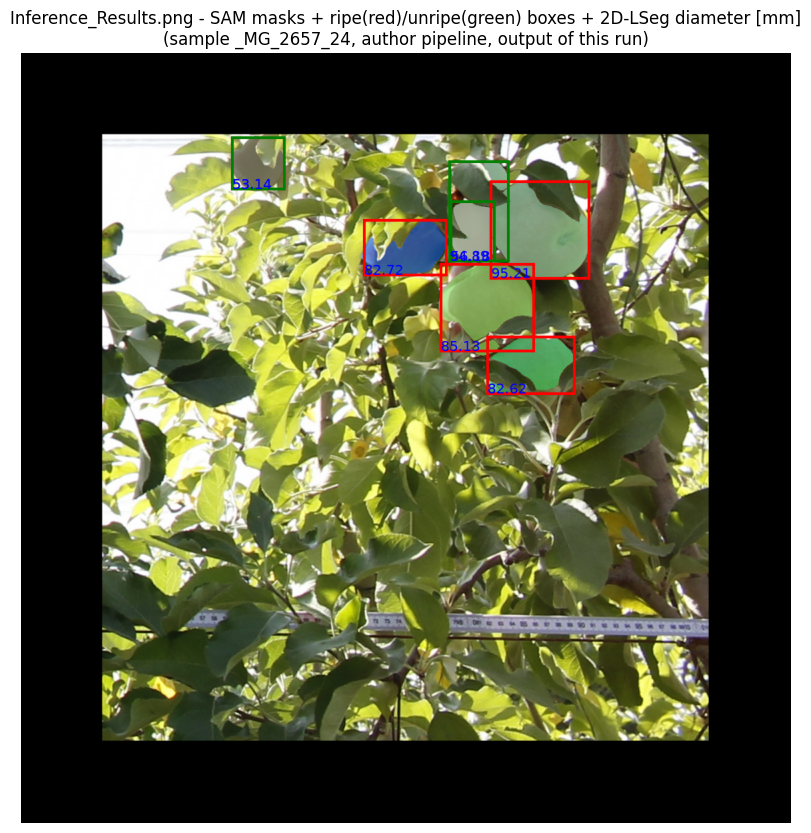

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
overlay = mpimg.imread("/content/out/Inference_Results.png")
plt.figure(figsize=(10, 10))
plt.imshow(overlay)
plt.axis("off")
plt.title("Inference_Results.png - SAM masks + ripe(red)/unripe(green) boxes + 2D-LSeg diameter [mm]" + "\n(sample _MG_2657_24, author pipeline, output of this run)")
plt.show()

### Quantitative results table (six algorithms, millimeters) and CSV export
Each row is one detected apple: detection label (0 = Ripe, 1 = Unripe) and score from
Grounding-DINO, then the six diameters from the author's algorithms (2D: bbox, max_dist_mask =
2D-LSeg, hough_mask; 3D: largest_segment, least_square, bounded_ransac). -1 marks an algorithm
that refused the sample (e.g. Hough found no circle). Values are clipped to [40, 100] mm by the
author's code (r_min/r_max = 20/50 mm radius). / 6アルゴリズムの推定直径(mm)の表とCSVを出します。

In [ ]:
import pandas as pd
df = pd.read_csv("/content/out/sizes.csv")
ALGO_COLS = ["bbox", "max_dist_mask", "hough_mask", "largest_segment", "least_square", "bounded_ransac"]
df["label"] = df["label"].map({0: "Ripe", 1: "Unripe"})
print(df.to_string(index=False))
df.to_csv("/content/sizes_export.csv", index=False)
import json
res = json.load(open("/content/out/result.json"))
print("\ndevice:", res["device"], "| detect %.2fs | segment %.2fs" % (res["detect_time_s"], res["segment_time_s"]))

 apple  label  score      bbox  max_dist_mask  hough_mask  largest_segment  least_square  bounded_ransac
     0   Ripe  0.756 82.739787      85.134468   93.417230        80.725082     98.711289       88.229171
     1   Ripe  0.751 87.030167      95.212692   76.524859        94.717497    100.000000       96.234890
     2   Ripe  0.707 76.801902      82.615315  100.000000        78.189308    100.000000       96.627643
     3   Ripe  0.528 78.457257      82.723648   95.309607        71.545490    100.000000       92.185614
     4   Ripe  0.441 51.033402      53.136915   52.405086        51.810217    100.000000       58.540384
     5 Unripe  0.378 51.106342      53.136915   52.405086        51.810217     99.999986      100.000000
     6 Unripe  0.367 53.809720      56.178475   40.000000        52.051305     81.507492       40.000000
     7 Unripe  0.306 90.292803      94.893891   40.000000        91.705593    100.000000      100.000000

device: cuda:0 | detect 3.34s | segment 2.09s


### Model outputs sanity check (no ground truth needed)
This sample has no per-apple caliper ground truth in the released test set, so we check
plausibility instead of equivalence: Fuji apples are typically 70–85 mm, the author clips to
[40, 100] mm, and the paper reports 2D-LSeg as the most accurate algorithm (median error near 0,
Fig. 9). Ripe apples (red surface) should also dominate the July…October captures. We display
the box-only overlay so the detection and masks can be judged separately from the sizes.
/ このサンプルにはキャリパー真値がないため、妥当性(40–100mm範囲、論文のFig.9の傾向)を確認します。

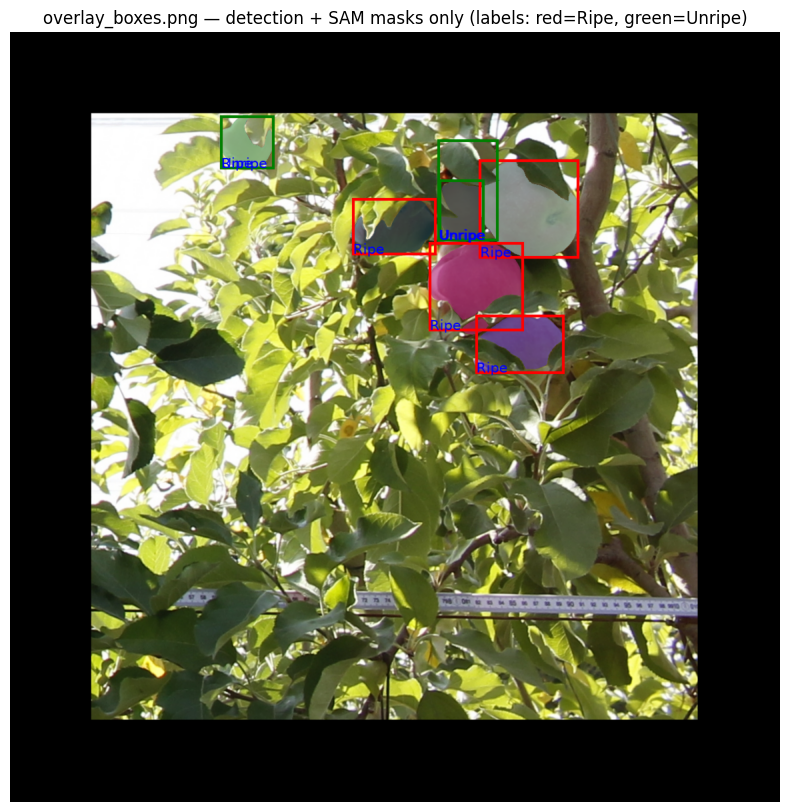

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
overlay = mpimg.imread("/content/out/overlay_boxes.png")
plt.figure(figsize=(10, 10))
plt.imshow(overlay)
plt.axis("off")
plt.title("overlay_boxes.png — detection + SAM masks only (labels: red=Ripe, green=Unripe)")
plt.show()

## 4. Interpretation, differences from the paper, limitations / 解釈・論文との違い・限界
- **What was reproduced**: the author's released inference path (commit `a0b7106`) on the exact
  sample named in `inference.py` — fine-tuned Grounding-DINO (Swin-B) detection with the
  `"ripe. unripe."` prompt at score 0.3, SAM ViT-H box-prompted masks, and all six size
  algorithms with the UdL focal length 5805.34 and 30–70% depth outlier removal. The overlay
  reproduces the released `Inference_Results.jpg` format (masks + colored boxes + mm labels).
- **Scope**: one image. This does not validate the paper's dataset-level detection accuracy
  (mAP50 85.9 for Grounding-DINO Swin-B, Table 1) or the sizing error distributions
  (Figures 9–10). No per-apple caliper ground truth ships with the released test split, so no
  quantitative size-accuracy claim is possible here.
- **Faithful reuse**: all scientific functions are copied verbatim from the pinned repository
  (see file/line citations in the cells); the pipeline text is embedded in this notebook so the
  learner can read every operation. mmdet 3.3.0 + mmcv 2.1.0 + torch 2.1.2 replace the README's
  torch 1.13.1+cu117 (1.13 has no wheels for available Pythons; 2.1.2 is the closest maintained
  build compatible with mmcv 2.1.0 prebuilt wheels). The config/checkpoint come from the
  author's own Kaggle upload, so model weights are the paper's own.
- **Known limitations**: ripeness labels derive from surface color and capture date, not an
  expert standard (paper §2.1); no license file exists in the repository (code copied here with
  attribution for educational use); depth/point-cloud methods depend on the D435i depth quality
  of this single sample; SAM is the generic official checkpoint (no apple-specific training).

### References
1. Zhu, K. et al. *Foundation Model-Based Apple Ripeness and Size Estimation for Selective
   Harvesting.* arXiv:2502.01850v1, 2025. https://arxiv.org/abs/2502.01850
2. Code: https://github.com/zhukeyi-stan/Fuji_Ripeness_And_Size_Estimation @ `a0b7106`
3. Dataset & checkpoint: https://www.kaggle.com/datasets/zhukeyi1/fuji-ripeness-and-size-dataset
4. Segment Anything: https://github.com/facebookresearch/segment-anything (official ViT-H checkpoint)
5. Grounding DINO (mmdetection 3.3.0): https://github.com/open-mmlab/mmdetection / https://github.com/IDEA-Research/GroundingDINO
6. OpenAcces_RGBD_Apple_Dataset (Unibo) & AmodalAppleSize_RGB-D (UdL) — source datasets of the
   Fuji-Ripeness-Size Dataset, cited by the paper §2.1.

/ 日本語まとめ: このノートブックは論文の推論パス(微調整済みGrounding-DINOによる熟度検出、
SAMによるセグメンテーション、6種のサイズ推定アルゴリズム)を著者リポジトリのコードをそのまま
用いて1枚のRGB-Dサンプルで再現します。単一画像の実行であり、論文のデータセット全体の精度
(Table 1, Fig. 9–10)の検証ではありません。T4 GPU推奨、CPUでも動作します。